#### **Assignment 3: Regularization and Distances**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

#### **1. Regularization Study**

**Importing necessary libraries**

**Loading the dataset**

**EDA**

**Pre-processing**

**Ridge**

**Lasso**

**Elastic Net**

**Cross validation**

**Conclusion**

#### **2. Distances and Clustering in DNA-Like Sequences**

**Importing necessary libraries**

In [1]:
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
from itertools import product
from scipy.spatial.distance import hamming, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering      
import hdbscan  
from statistics import mean                                     
from sklearn.manifold import MDS, TSNE
import umap
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

**Loading the dataset**

In [2]:
data=pd.read_csv("./data/highly_classified_data.csv",sep=";")
data.head()

,ID,Sequence,Unnamed: 2
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...,NaN
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN


In [3]:
print(data['Unnamed: 2'].value_counts())
# Dropping the 'Unnamed: 2' column as it contains NaN 
data = data.drop(columns=['Unnamed: 2'])
data.sample(4)

Series([], Name: count, dtype: int64)


,ID,Sequence
83,seq84,GGAGGATTGAGGTTCAGTATCACCAAGTGCCTGACCAGGTGGTTAA...
53,seq54,ATAGGAGGTTTCGCGAAGTGGGTGATAGCCGATGGTAGCCGGCCCA...
70,seq71,ATAGGAGGTTTCGCGGAGTGGGTGATATCAGATTGTAGCCGGCCCA...
45,seq46,TTGCCGGACGTTCCCAGAGCTCCGGATGTGAACTTCGTTCACTGAT...


**EDA**

In [4]:
# Checking for missing values
print("Missing values in each column:")
print(data.isnull().sum())
# Checking for duplicates
print("Number of duplicate rows:", data.duplicated().sum())
# Length of the sequences
print("Average length of the sequences:", mean(data['Sequence'].apply(len)))
# Unique characters in the sequences
unique_characters = set(''.join(data['Sequence'].tolist()))
print(f"Unique characters in the sequences: {sorted(unique_characters)}")

Missing values in each column:
ID          0
Sequence    0
dtype: int64
Number of duplicate rows: 0
Average length of the sequences: 10000
Unique characters in the sequences: ['A', 'C', 'G', 'T']


In [5]:
# Checking for malformed sequences (non-ACGT characters)
data["valid"] = data["Sequence"].apply(lambda s: set(s).issubset(set("ACGT")))
print(f"Malformed sequences: {(~data['valid']).sum()}")

Malformed sequences: 0


- No sequences are malformed as all of them contain only A, C, G, T nucleotides

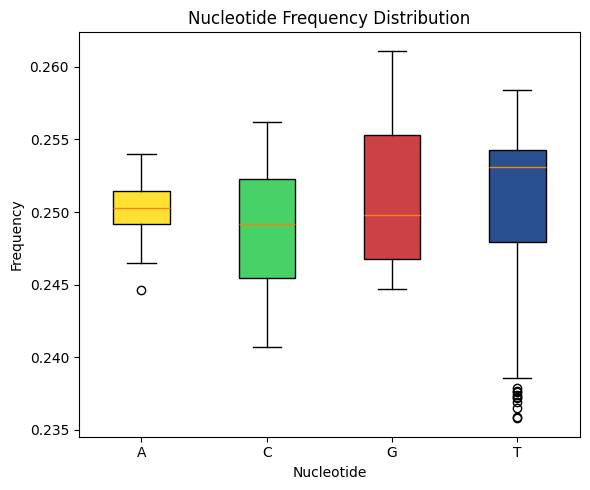

In [6]:
# Calculating frequency of each unique character in the sequences
for nuc in sorted(unique_characters):
    data[f"freq_{nuc}"] = data["Sequence"].apply(lambda s: s.count(nuc) / len(s))
fig, ax = plt.subplots(figsize=(6, 5))
freq_data = [data[f"freq_{n}"].values for n in sorted(unique_characters)]
bp = ax.boxplot(freq_data, labels=list(sorted(unique_characters)), patch_artist=True)
colors = ["#FFE134", "#47D167", "#CC4146", "#285091"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Nucleotide Frequency Distribution")
ax.set_ylabel("Frequency")
ax.set_xlabel("Nucleotide")
plt.tight_layout()
plt.show()

**Sequence representation**

In [7]:
def kmer_freq_vector(seq, k, kmer_list):
    """Computing k-mer frequency vector for a sequence."""
    total = len(seq) - k + 1
    counts = {km: 0 for km in kmer_list}
    for i in range(total):
        tri = seq[i:i+k]
        if tri in counts:
            counts[tri] += 1
    return np.array([counts[km] / total for km in kmer_list])
def normalized_hamming(s1, s2):
    """Computing normalized Hamming distance between two equal-length strings."""
    assert len(s1) == len(s2), "Sequences must be equal length for Hamming."
    return sum(c1 != c2 for c1, c2 in zip(s1, s2)) / len(s1)

In [8]:
# 1. Trinucleotide frequencies (k=3) (Euclidean distance)
k=3
seqs = data['Sequence'].tolist()
k_mers = [''.join(p) for p in product("ACGT", repeat=k)] #4^3=64 possible trinucleotides
kmer_matrix = np.array([kmer_freq_vector(s, k, k_mers) for s in seqs])
print(f"Trinucleotide frequency matrix shape: {kmer_matrix.shape}")

Trinucleotide frequency matrix shape: (100, 64)


In [9]:
# 2. Normalized Hamming distance matrix (Non-euclidean distance)
hamming_matrix = np.zeros((len(seqs), len(seqs)))
for i in range(len(seqs)):
    for j in range(i + 1, len(seqs)):
        d = normalized_hamming(seqs[i], seqs[j])
        hamming_matrix[i, j] = d
        hamming_matrix[j, i] = d
print(f"Hamming distance matrix shape: {hamming_matrix.shape}")
print(f"Mean pairwise distance: {hamming_matrix[hamming_matrix > 0].mean():.4f}")

Hamming distance matrix shape: (100, 100)
Mean pairwise distance: 0.5829


**Distance matrix**

**Clustering**

**Dimensionality reduction**

**Cluster validation**

**Within cluster sequence analysis**

**Metrics Conclusion**

**Conclusion**

**Take-away**

**1. Regularization**

- 
- 



**2. Distances**

- 
- 